# Блок 4. Нейронная сеть прямого распространения для регрессии

В этом ноутбуке решается задача регрессии на новом датасете `California Housing`.
Используется полносвязная нейронная сеть `MLPRegressor`, а качество модели оценивается
по нескольким регрессионным метрикам на отложенной тестовой выборке.

## О датасете California Housing

Датасет `California Housing` содержит `20640` наблюдений и `8` числовых признаков.
Каждый объект описывает район штата Калифорния по социально-экономическим и географическим характеристикам.

Целевая переменная - `target`, то есть медианная стоимость жилья в районе.
Это классическая задача регрессии: по набору признаков требуется предсказать непрерывное числовое значение.

Датасет хорошо подходит для нейросетевого регрессора, потому что содержит достаточно много объектов,
а зависимость между признаками и ценой жилья не обязательно является строго линейной.

In [4]:
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)
sns.set_theme(style="whitegrid")

housing = fetch_california_housing()
df_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
df_housing["target"] = housing.target

print(f"Размер датасета: {df_housing.shape}")
display(df_housing.head())

Размер датасета: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Первичный анализ данных

На этом шаге проверяются:

1. структура таблицы;
2. наличие пропусков;
3. описательная статистика;
4. распределение целевой переменной;
5. связи признаков с `target`.

Такой анализ нужен, чтобы понять масштаб признаков и предварительно оценить,
какие переменные могут быть полезны для предсказания цены жилья.

Информация о датасете:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   target      20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

Пропуски по столбцам:



,missing_count
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
target,0



Описательная статистика:



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


,corr_with_target
MedInc,0.688075
AveRooms,0.151948
Latitude,-0.144160
HouseAge,0.105623
AveBedrms,-0.046701
Longitude,-0.045967
Population,-0.024650
AveOccup,-0.023737


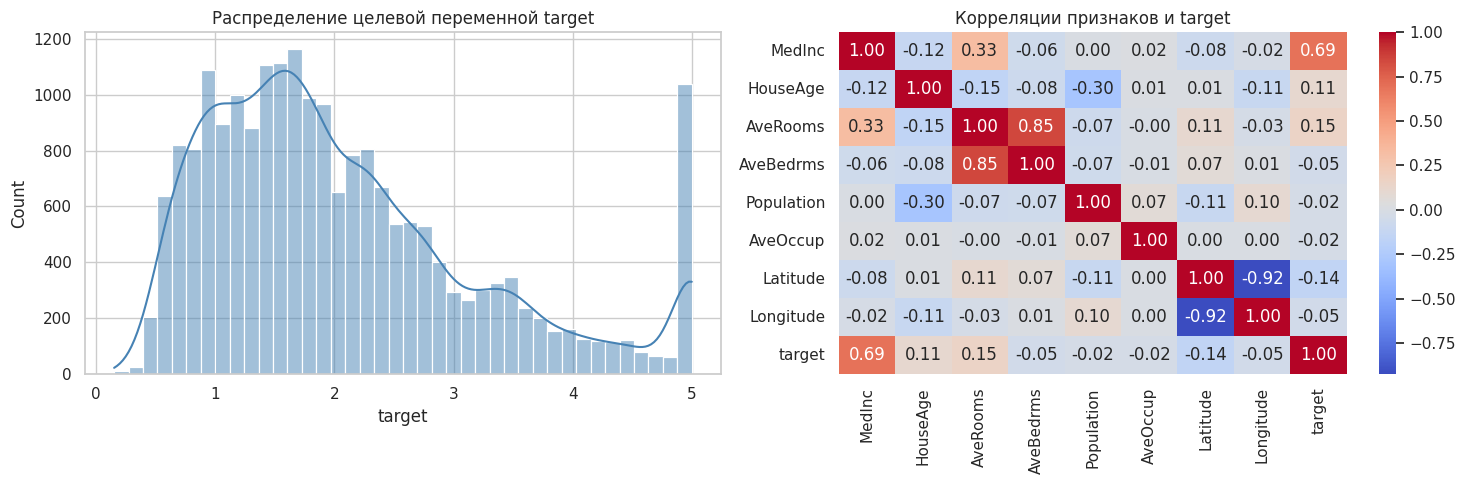

In [5]:
print("Информация о датасете:\n")
df_housing.info()

print("\nПропуски по столбцам:\n")
display(df_housing.isna().sum().to_frame(name="missing_count"))

print("\nОписательная статистика:\n")
display(df_housing.describe())

corr_with_target = df_housing.corr(numeric_only=True)["target"].drop("target").sort_values(key=lambda s: s.abs(), ascending=False)
display(corr_with_target.to_frame(name="corr_with_target"))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(df_housing["target"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Распределение целевой переменной target")
axes[0].set_xlabel("target")
axes[0].set_ylabel("Count")

sns.heatmap(df_housing.corr(numeric_only=True), cmap="coolwarm", annot=True, fmt=".2f", ax=axes[1])
axes[1].set_title("Корреляции признаков и target")
plt.tight_layout()
plt.show()

## Подготовка данных и подбор конфигурации MLPRegressor

Данные делятся на три части:

- `train` - для обучения конфигураций;
- `validation` - для выбора лучшей архитектуры;
- `test` - для финальной независимой оценки.

Для нейронной сети признаки стандартизуются. Целевая переменная также масштабируется через
`TransformedTargetRegressor`, чтобы обучение было стабильнее.

Вместо большого `GridSearchCV` сравнивается небольшой набор заранее выбранных конфигураций,
что делает ноутбук более прозрачным и умеренным по времени выполнения.

In [6]:
X = df_housing.drop(columns=["target"])
y = df_housing["target"]

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
)

print(f"Размер train: {X_train.shape}")
print(f"Размер validation: {X_val.shape}")
print(f"Размер test: {X_test.shape}")


def build_regressor(hidden_layer_sizes, alpha, learning_rate_init):
    regressor = Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "mlp",
                MLPRegressor(
                    hidden_layer_sizes=hidden_layer_sizes,
                    alpha=alpha,
                    learning_rate_init=learning_rate_init,
                    activation="relu",
                    solver="adam",
                    max_iter=400,
                    early_stopping=True,
                    validation_fraction=0.1,
                    n_iter_no_change=20,
                    random_state=42,
                ),
            ),
        ]
    )

    return TransformedTargetRegressor(
        regressor=regressor,
        transformer=StandardScaler(),
    )


candidate_configs = [
    {"hidden_layer_sizes": (64,), "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (128,), "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (128, 64), "alpha": 1e-4, "learning_rate_init": 1e-3},
    {"hidden_layer_sizes": (128, 64), "alpha": 1e-3, "learning_rate_init": 5e-4},
]

validation_rows = []

for idx, config in enumerate(candidate_configs, start=1):
    model = build_regressor(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        alpha=config["alpha"],
        learning_rate_init=config["learning_rate_init"],
    )
    model.fit(X_train, y_train)
    y_val_pred = model.predict(X_val)

    validation_rows.append(
        {
            "Конфигурация": f"Model {idx}",
            "hidden_layer_sizes": config["hidden_layer_sizes"],
            "alpha": config["alpha"],
            "learning_rate_init": config["learning_rate_init"],
            "MSE": mean_squared_error(y_val, y_val_pred),
            "RMSE": np.sqrt(mean_squared_error(y_val, y_val_pred)),
            "MAE": mean_absolute_error(y_val, y_val_pred),
            "MAPE": mean_absolute_percentage_error(y_val, y_val_pred),
            "R2": r2_score(y_val, y_val_pred),
        }
    )

validation_df = pd.DataFrame(validation_rows).sort_values(by=["RMSE", "MAE"]).reset_index(drop=True)
validation_display = validation_df.copy()
metric_cols = ["MSE", "RMSE", "MAE", "MAPE", "R2"]
validation_display[metric_cols] = validation_display[metric_cols].round(4)

best_config = validation_df.iloc[0]
best_model = build_regressor(
    hidden_layer_sizes=best_config["hidden_layer_sizes"],
    alpha=float(best_config["alpha"]),
    learning_rate_init=float(best_config["learning_rate_init"]),
)
best_model.fit(X_train_full, y_train_full)

y_test_pred = best_model.predict(X_test)
test_results_df = pd.DataFrame(
    {
        "Метрика": ["MSE", "RMSE", "MAE", "MAPE", "R^2"],
        "Значение": [
            mean_squared_error(y_test, y_test_pred),
            np.sqrt(mean_squared_error(y_test, y_test_pred)),
            mean_absolute_error(y_test, y_test_pred),
            mean_absolute_percentage_error(y_test, y_test_pred),
            r2_score(y_test, y_test_pred),
        ],
    }
)
test_results_df["Значение"] = test_results_df["Значение"].round(4)

print("Сравнение конфигураций на validation:")
display(validation_display)

print("Лучшая конфигурация:")
print(best_config[["Конфигурация", "hidden_layer_sizes", "alpha", "learning_rate_init"]])

print("\nМетрики лучшей модели на test:")
display(test_results_df)

Размер train: (13209, 8)
Размер validation: (3303, 8)
Размер test: (4128, 8)
Сравнение конфигураций на validation:


,Конфигурация,hidden_layer_sizes,alpha,learning_rate_init,MSE,RMSE,MAE,MAPE,R2
0,Model 3,"(128, 64)",0.0001,0.0010,0.2899,0.5384,0.3649,0.2018,0.7899
1,Model 4,"(128, 64)",0.0010,0.0005,0.2935,0.5417,0.3664,0.2046,0.7873
2,Model 1,"(64,)",0.0001,0.0010,0.3118,0.5584,0.3826,0.2141,0.7741
3,Model 2,"(128,)",0.0001,0.0010,0.5744,0.7579,0.3940,0.2187,0.5838


Лучшая конфигурация:
Конфигурация            Model 3
hidden_layer_sizes    (128, 64)
alpha                    0.0001
learning_rate_init        0.001
Name: 0, dtype: object

Метрики лучшей модели на test:


,Метрика,Значение
0,MSE,0.2719
1,RMSE,0.5214
2,MAE,0.3508
3,MAPE,0.1955
4,R^2,0.7925


## Анализ ошибок и визуализация качества модели

После выбора лучшей конфигурации полезно посмотреть не только на сами метрики,
но и на поведение ошибок:

- насколько близки предсказания к реальным значениям;
- как распределены остатки;
- как убывала функция потерь во время обучения.

Это помогает понять, обучилась ли модель устойчиво и не возникает ли явного систематического смещения.

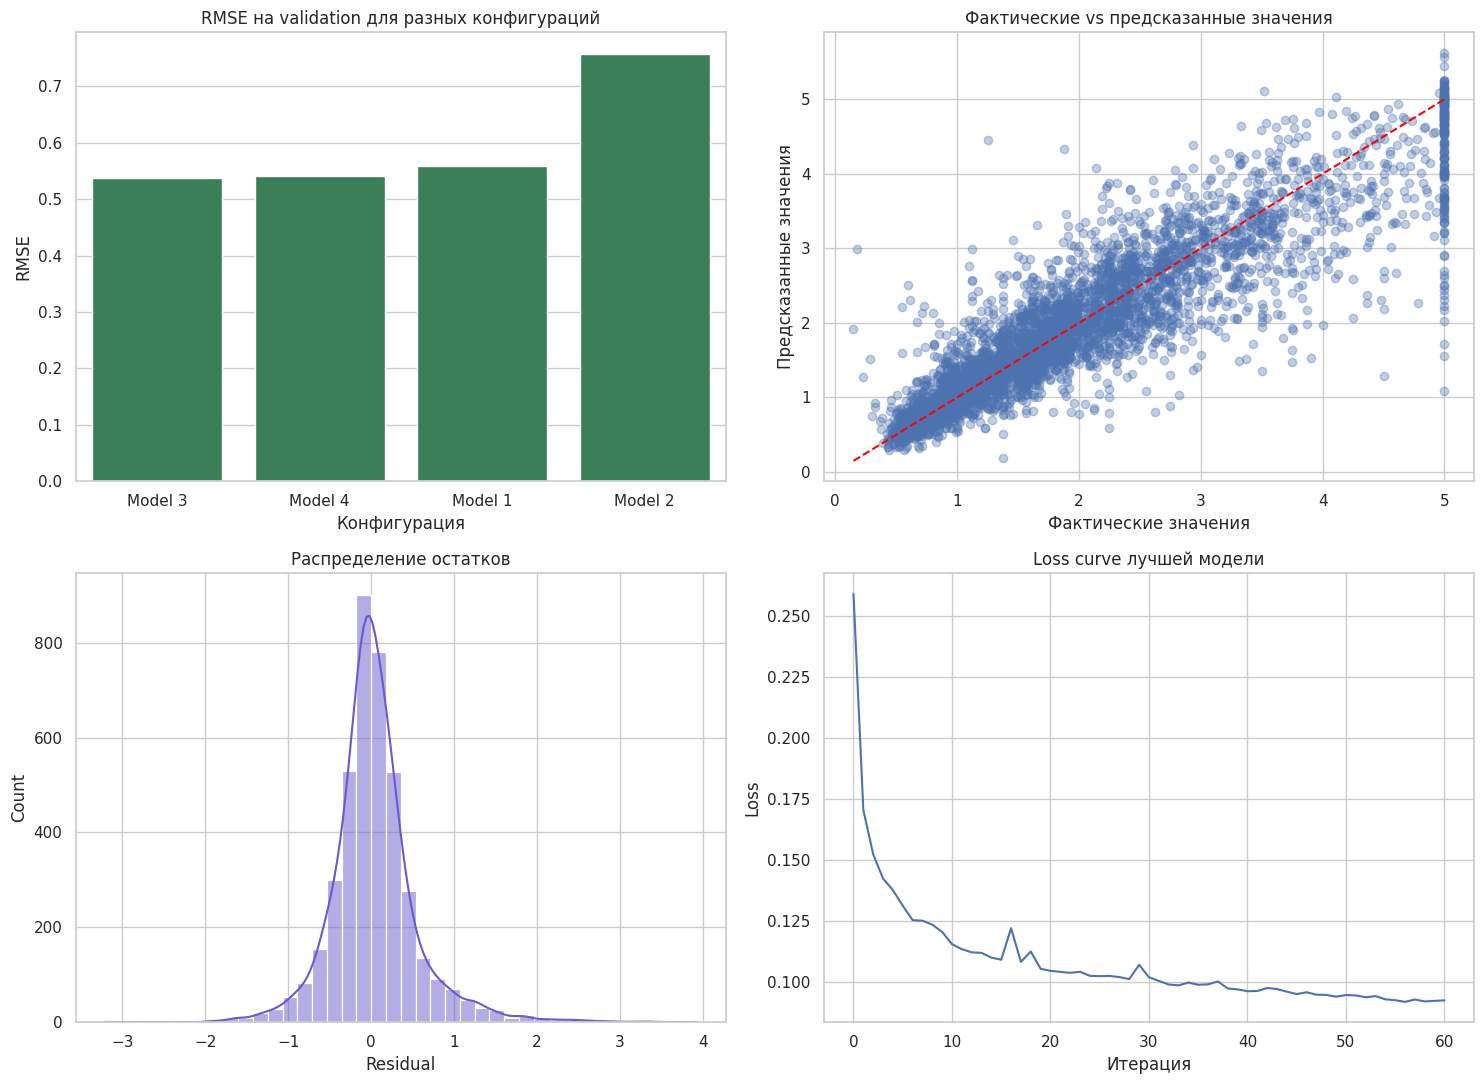

In [7]:
residuals = y_test - y_test_pred
best_mlp = best_model.regressor_.named_steps["mlp"]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

sns.barplot(data=validation_display, x="Конфигурация", y="RMSE", color="seagreen", ax=axes[0, 0])
axes[0, 0].set_title("RMSE на validation для разных конфигураций")
axes[0, 0].set_xlabel("Конфигурация")
axes[0, 0].set_ylabel("RMSE")

axes[0, 1].scatter(y_test, y_test_pred, alpha=0.35)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
axes[0, 1].set_title("Фактические vs предсказанные значения")
axes[0, 1].set_xlabel("Фактические значения")
axes[0, 1].set_ylabel("Предсказанные значения")

sns.histplot(residuals, bins=40, kde=True, color="slateblue", ax=axes[1, 0])
axes[1, 0].set_title("Распределение остатков")
axes[1, 0].set_xlabel("Residual")
axes[1, 0].set_ylabel("Count")

axes[1, 1].plot(best_mlp.loss_curve_)
axes[1, 1].set_title("Loss curve лучшей модели")
axes[1, 1].set_xlabel("Итерация")
axes[1, 1].set_ylabel("Loss")

plt.tight_layout()
plt.show()

## Вывод

По итогам подбора лучшей конфигурацией оказался `MLPRegressor` с архитектурой `(128, 64)`,
`alpha = 0.0001` и `learning_rate_init = 0.001`. На validation он показал наименьший
`RMSE = 0.5384`, а на независимой test-выборке получил:

- `MSE = 0.2719`;
- `RMSE = 0.5214`;
- `MAE = 0.3508`;
- `MAPE = 0.1955`;
- `R^2 = 0.7925`.

Это означает, что модель объясняет около `79%` вариации целевой переменной,
что для табличной задачи такого типа является хорошим результатом.
При этом архитектура `(128,)` с тем же `learning_rate_init` сработала заметно хуже,
поэтому более глубокая сеть здесь действительно оказалась полезной.

Полученные графики должны интерпретироваться так:

- scatter `фактические vs предсказанные` показывает, насколько предсказания близки к диагонали;
- распределение остатков позволяет увидеть, нет ли сильного систематического смещения;
- `loss curve` показывает, что обучение лучшей модели шло устойчиво и функция потерь снижалась.

Итог: `MLPRegressor` хорошо справился с задачей предсказания стоимости жилья,
но часть ошибки остаётся ожидаемой из-за шума в данных, сложной нелинейности зависимости
и наличия районов с экстремальными значениями target.